# Exploratory Data Analysis — SBA National Loan Dataset

This notebook explores the U.S. Small Business Administration (SBA) loan dataset.  
The key business question is: **what factors predict whether a small business loan will default (CHGOFF) or be paid in full (P I F)?**

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean plot style and default figure size
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
# Load the dataset — low_memory=False avoids dtype inference warnings on large files
df = pd.read_csv("../data/SBAnational.csv", low_memory=False)
print(f"Shape: {df.shape}")
df.head()

Shape: (899164, 27)


,LoanNr_ChkDgt,Name,City,State,Zip,Bank,BankState,NAICS,ApprovalDate,ApprovalFY,...,RevLineCr,LowDoc,ChgOffDate,DisbursementDate,DisbursementGross,BalanceGross,MIS_Status,ChgOffPrinGr,GrAppv,SBA_Appv
0,1000014003,ABC HOBBYCRAFT,EVANSVILLE,IN,47711,FIFTH THIRD BANK,OH,451120,28-Feb-97,1997,...,N,Y,NaN,28-Feb-99,"$60,000.00",$0.00,P I F,$0.00,"$60,000.00","$48,000.00"
1,1000024006,LANDMARK BAR & GRILLE (THE),NEW PARIS,IN,46526,1ST SOURCE BANK,IN,722410,28-Feb-97,1997,...,N,Y,NaN,31-May-97,"$40,000.00",$0.00,P I F,$0.00,"$40,000.00","$32,000.00"
2,1000034009,"WHITLOCK DDS, TODD M.",BLOOMINGTON,IN,47401,GRANT COUNTY STATE BANK,IN,621210,28-Feb-97,1997,...,N,N,NaN,31-Dec-97,"$287,000.00",$0.00,P I F,$0.00,"$287,000.00","$215,250.00"
3,1000044001,"BIG BUCKS PAWN & JEWELRY, LLC",BROKEN ARROW,OK,74012,1ST NATL BK & TR CO OF BROKEN,OK,0,28-Feb-97,1997,...,N,Y,NaN,30-Jun-97,"$35,000.00",$0.00,P I F,$0.00,"$35,000.00","$28,000.00"
4,1000054004,"ANASTASIA CONFECTIONS, INC.",ORLANDO,FL,32801,FLORIDA BUS. DEVEL CORP,FL,0,28-Feb-97,1997,...,N,N,NaN,14-May-97,"$229,000.00",$0.00,P I F,$0.00,"$229,000.00","$229,000.00"


## 1. Data Types & Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 899164 entries, 0 to 899163
Data columns (total 27 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   LoanNr_ChkDgt      899164 non-null  int64  
 1   Name               899150 non-null  str    
 2   City               899134 non-null  str    
 3   State              899150 non-null  str    
 4   Zip                899164 non-null  int64  
 5   Bank               897605 non-null  str    
 6   BankState          897598 non-null  str    
 7   NAICS              899164 non-null  int64  
 8   ApprovalDate       899164 non-null  str    
 9   ApprovalFY         899164 non-null  str    
 10  Term               899164 non-null  int64  
 11  NoEmp              899164 non-null  int64  
 12  NewExist           899028 non-null  float64
 13  CreateJob          899164 non-null  int64  
 14  RetainedJob        899164 non-null  int64  
 15  FranchiseCode      899164 non-null  int64  
 16  UrbanRural   

The dataset has ~900k rows and 27 columns. Most columns are a mix of strings (names, dates, flags) and numerics. Several currency columns are stored as strings and will need cleaning before analysis.

## Data Dictionary

| Column | Type | Description |
|---|---|---|
| `LoanNr_ChkDgt` | string | Unique loan identifier with check digit |
| `Name` | string | Name of the borrowing business |
| `City` | string | City where the business is located |
| `State` | string | State where the business is located |
| `Zip` | string | Zip code of the business |
| `Bank` | string | Name of the lending bank |
| `BankState` | string | State where the lending bank is based |
| `NAICS` | int | 6-digit North American Industry Classification System code — identifies the business's industry sector |
| `ApprovalDate` | string | Date the loan was approved |
| `ApprovalFY` | int | Fiscal year the loan was approved |
| `Term` | int | Loan term in months |
| `NoEmp` | int | Number of employees at the business |
| `NewExist` | int | Business age — `1` = existing business, `2` = new business |
| `CreateJob` | int | Number of jobs created as a result of the loan |
| `RetainedJob` | int | Number of jobs retained as a result of the loan |
| `FranchiseCode` | int | Franchise indicator — `1` = not a franchise, any other value = franchise code |
| `UrbanRural` | int | Location type — `1` = urban, `2` = rural, `0` = undefined |
| `RevLineCr` | string | Revolving line of credit — `Y` = yes, `N` = no |
| `LowDoc` | string | Low documentation loan program — `Y` = yes (simplified paperwork), `N` = no |
| `ChgOffDate` | string | Date the loan was charged off (only populated if the loan defaulted) |
| `DisbursementDate` | string | Date the loan funds were disbursed to the borrower |
| `DisbursementGross` | float | Gross dollar amount disbursed to the borrower |
| `BalanceGross` | float | Gross outstanding balance remaining on the loan |
| `MIS_Status` | string | **Target variable** — final loan status: `P I F` = Paid in Full, `CHGOFF` = Charged Off (defaulted) |
| `ChgOffPrinGr` | float | Gross principal amount charged off at default |
| `GrAppv` | float | Gross loan amount approved by the bank |
| `SBA_Appv` | float | Dollar amount of the loan guaranteed by the SBA |

## 2. Missing Values

In [4]:
# Count nulls per column and express as a percentage of total rows
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)

# Combine into a single table and show only columns that have at least one missing value
missing_df = pd.DataFrame({"Missing": missing, "% Missing": missing_pct})
missing_df[missing_df["Missing"] > 0].sort_values("% Missing", ascending=False)

,Missing,% Missing
ChgOffDate,736465,81.91
RevLineCr,4528,0.50
LowDoc,2582,0.29
DisbursementDate,2368,0.26
MIS_Status,1997,0.22
Bank,1559,0.17
BankState,1566,0.17
NewExist,136,0.02
Name,14,0.00
City,30,0.00


`ChgOffDate` is missing for most rows — expected, as it only applies to defaulted loans. `Name`, `NewExist`, and `BankState` have small amounts of missing data that may need imputing or dropping before modelling.

## 3. Target Variable — Loan Status (MIS_Status)

MIS_Status
P I F     739609
CHGOFF    157558
NaN         1997
Name: count, dtype: int64

Default rate: 17.52%


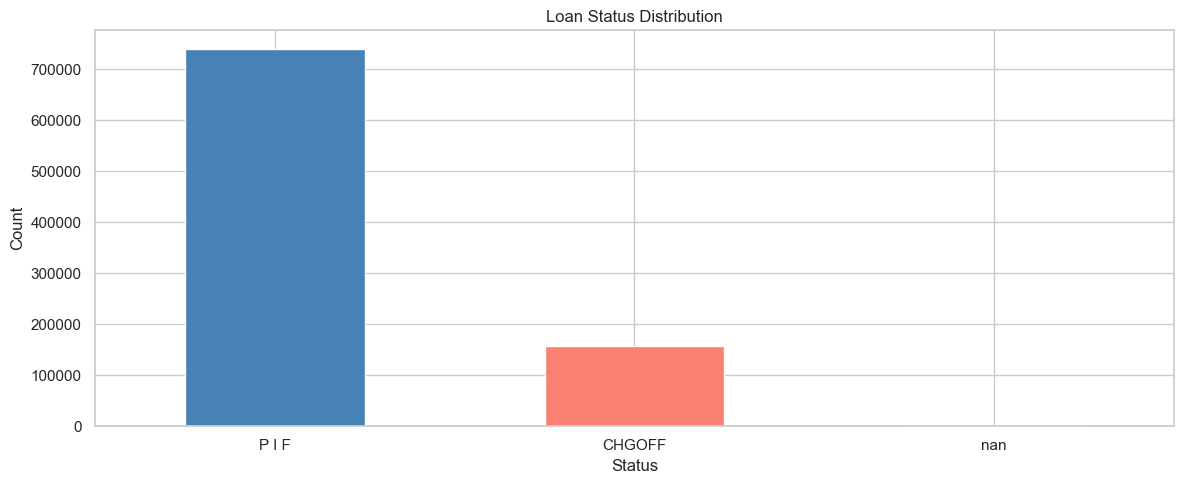

In [5]:
# Strip whitespace from MIS_Status — raw values sometimes have trailing spaces
df["MIS_Status"] = df["MIS_Status"].str.strip()

# Count each loan status, including NaN rows
status_counts = df["MIS_Status"].value_counts(dropna=False)
print(status_counts)

# Calculate the overall default rate (CHGOFF = charged off / defaulted)
print(f"\nDefault rate: {(status_counts.get('CHGOFF', 0) / status_counts.sum() * 100):.2f}%")

fig, ax = plt.subplots()
status_counts.plot(kind="bar", ax=ax, color=["steelblue", "salmon", "gray"])
ax.set_title("Loan Status Distribution")
ax.set_xlabel("Status")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

The majority of loans were paid in full. Roughly **17% defaulted** (CHGOFF), making this a moderately imbalanced classification problem — worth keeping in mind when choosing a model and evaluation metric.

## 4. Numeric Feature Distributions

In [6]:
# Currency columns are stored as strings like "$60,000.00 "
# Strip $, commas, and whitespace then cast to float
currency_cols = ["DisbursementGross", "BalanceGross", "ChgOffPrinGr", "GrAppv", "SBA_Appv"]
for col in currency_cols:
    df[col] = (
        df[col].astype(str)
        .str.replace(r"[\$,\s]", "", regex=True)
        .pipe(pd.to_numeric, errors="coerce")  # unparseable values become NaN
    )

# Columns to summarise numerically
numeric_cols = ["Term", "NoEmp", "CreateJob", "RetainedJob",
                "DisbursementGross", "GrAppv", "SBA_Appv"]

# Transpose so each feature is a row — easier to scan than the default layout
df[numeric_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Term,899164.0,110.77,78.86,0.0,60.0,84.0,120.0,569.0
NoEmp,899164.0,11.41,74.11,0.0,2.0,4.0,10.0,9999.0
CreateJob,899164.0,8.43,236.69,0.0,0.0,0.0,1.0,8800.0
RetainedJob,899164.0,10.80,237.12,0.0,0.0,1.0,4.0,9500.0
DisbursementGross,899164.0,201154.02,287640.85,0.0,42000.0,100000.0,238000.0,11446325.0
GrAppv,899164.0,192686.98,283263.39,200.0,35000.0,90000.0,225000.0,5472000.0
SBA_Appv,899164.0,149488.79,228414.56,100.0,21250.0,61250.0,175000.0,5472000.0


Loan amounts (`GrAppv`, `SBA_Appv`, `DisbursementGross`) are heavily right-skewed — a small number of very large loans pull the mean well above the median. `NoEmp`, `CreateJob`, and `RetainedJob` are also skewed. Log-transformation may be useful before modelling.

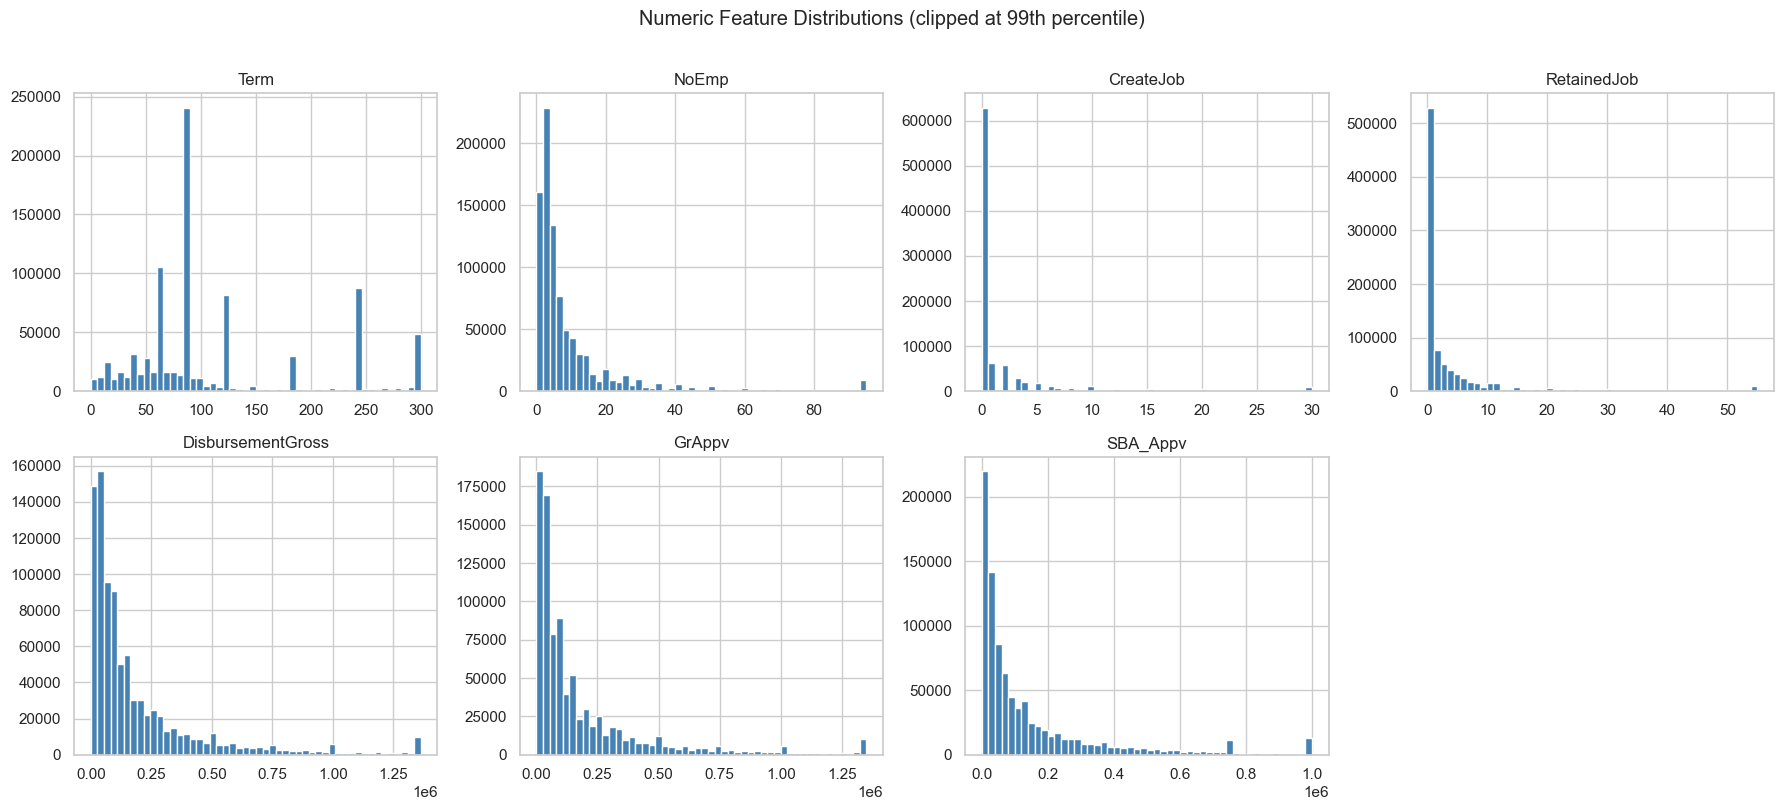

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    # Clip at the 99th percentile so extreme outliers don't compress the histogram
    axes[i].hist(df[col].dropna().clip(upper=df[col].quantile(0.99)), bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(col)
    axes[i].set_xlabel("")

# Hide any unused subplot panels (grid has 8 slots, we only need 7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Feature Distributions (clipped at 99th percentile)", y=1.01)
plt.tight_layout()
plt.show()

All monetary and count features show strong right skew — most loans are small and short-term, with a long tail of larger ones. `Term` clusters around common durations (60, 84, 120, 240 months).

## 5. Default Rate by Key Categorical Features

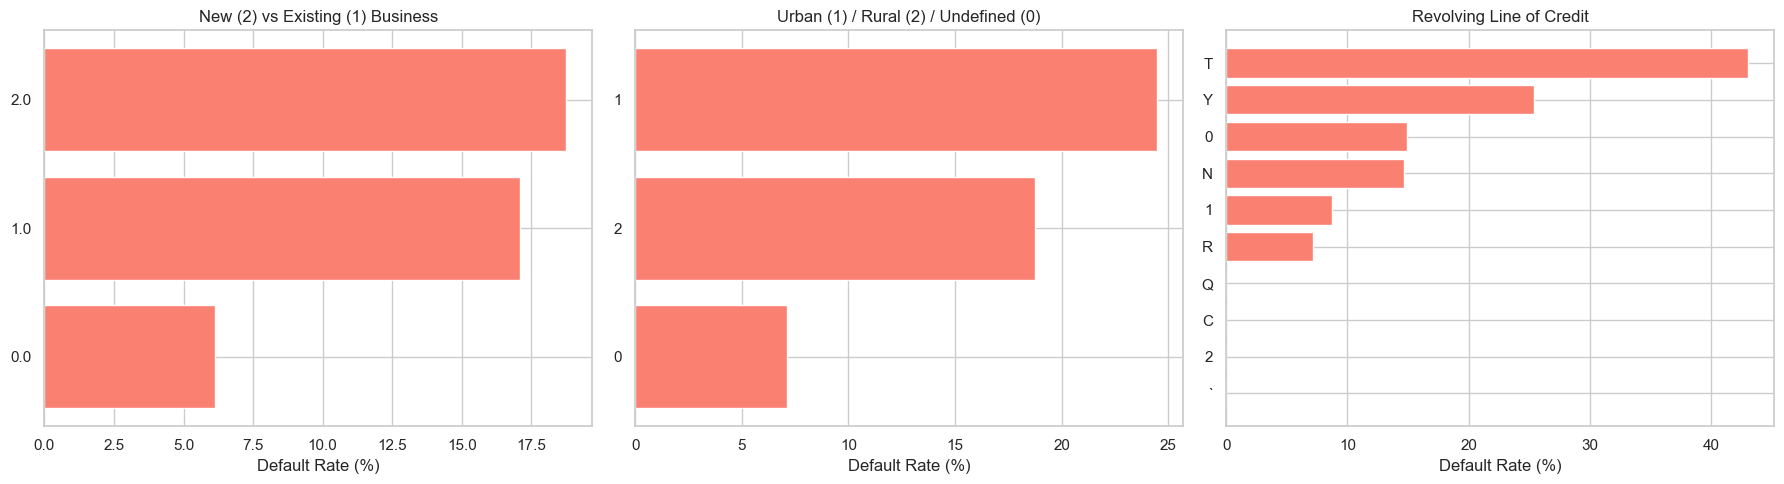

In [8]:
# Drop rows without a final loan status (unlabelled) — these can't be used for default analysis
labelled = df[df["MIS_Status"].isin(["P I F", "CHGOFF"])].copy()

# Create a binary target: 1 = defaulted (charged off), 0 = paid in full
labelled["Defaulted"] = (labelled["MIS_Status"] == "CHGOFF").astype(int)

def default_rate_bar(col, title, ax, top_n=10):
    """Plot a horizontal bar chart of default rate for each category in `col`."""
    rates = (
        labelled.groupby(col)["Defaulted"]
        .agg(["mean", "count"])
        .rename(columns={"mean": "default_rate", "count": "n"})
        .sort_values("n", ascending=False)
        .head(top_n)                              # keep only the top_n most common categories
        .sort_values("default_rate", ascending=True)  # sort bars by rate for readability
    )
    ax.barh(rates.index.astype(str), rates["default_rate"] * 100, color="salmon")
    ax.set_xlabel("Default Rate (%)")
    ax.set_title(title)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# NewExist: 1 = existing business, 2 = new business
default_rate_bar("NewExist",    "New (2) vs Existing (1) Business", axes[0])
# UrbanRural: 1 = urban, 2 = rural, 0 = undefined
default_rate_bar("UrbanRural",  "Urban (1) / Rural (2) / Undefined (0)", axes[1])
# RevLineCr: Y = revolving line of credit, N = term loan
default_rate_bar("RevLineCr",   "Revolving Line of Credit", axes[2])

plt.tight_layout()
plt.show()

**New businesses** default at a noticeably higher rate than existing ones — they lack trading history and cash flow stability. **Revolving lines of credit** also show a higher default rate than standard term loans, likely because they attract higher-risk borrowers. Urban/rural location has minimal impact.

## 6. Default Rate by State (Top 20 States by Volume)

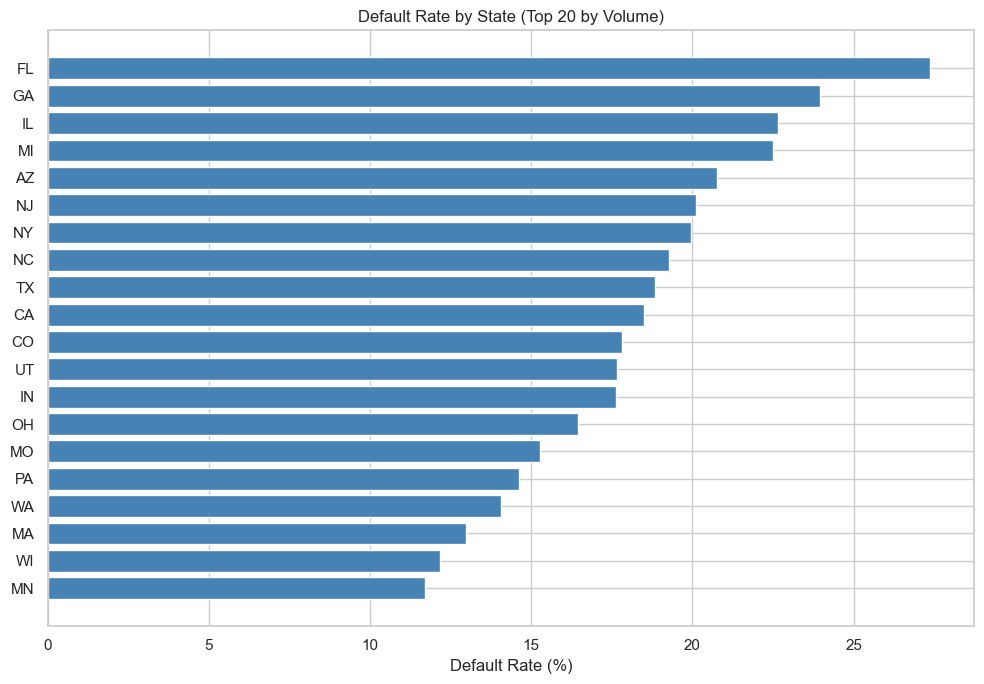

In [9]:
# Limit to the 20 states with the most loans to avoid noise from small-sample states
state_rates = (
    labelled.groupby("State")["Defaulted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n"})
    .sort_values("n", ascending=False)
    .head(20)
    .sort_values("default_rate", ascending=True)  # sort for easier visual comparison
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(state_rates.index, state_rates["default_rate"] * 100, color="steelblue")
ax.set_xlabel("Default Rate (%)")
ax.set_title("Default Rate by State (Top 20 by Volume)")
plt.tight_layout()
plt.show()

Default rates vary meaningfully by state. Some states consistently perform above or below the national average, reflecting regional economic conditions. This makes `State` a potentially useful feature for modelling.

## 7. Loan Amount vs Default

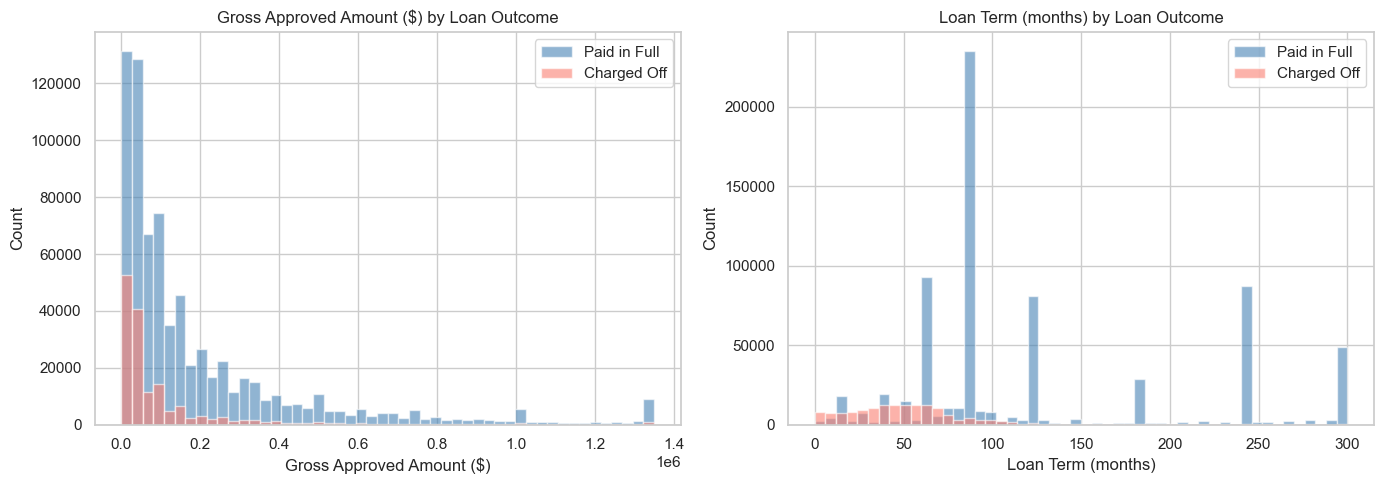

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, label in zip(axes, ["GrAppv", "Term"], ["Gross Approved Amount ($)", "Loan Term (months)"]):
    # Clip at 99th percentile to prevent outliers from flattening the histogram
    clip_val = labelled[col].quantile(0.99)
    pif = labelled.loc[labelled["MIS_Status"] == "P I F", col].clip(upper=clip_val).dropna()
    chg = labelled.loc[labelled["MIS_Status"] == "CHGOFF", col].clip(upper=clip_val).dropna()

    # Overlay both outcomes so differences in shape and centre are visible
    ax.hist(pif, bins=50, alpha=0.6, label="Paid in Full", color="steelblue")
    ax.hist(chg, bins=50, alpha=0.6, label="Charged Off", color="salmon")
    ax.set_xlabel(label)
    ax.set_ylabel("Count")
    ax.set_title(f"{label} by Loan Outcome")
    ax.legend()

plt.tight_layout()
plt.show()

Defaulted loans tend to have **longer terms** than paid-in-full loans — longer commitments carry more exposure to economic downturns. Loan amount distributions largely overlap, suggesting size alone is not a strong predictor of default.

## 8. SBA Guarantee Coverage Rate

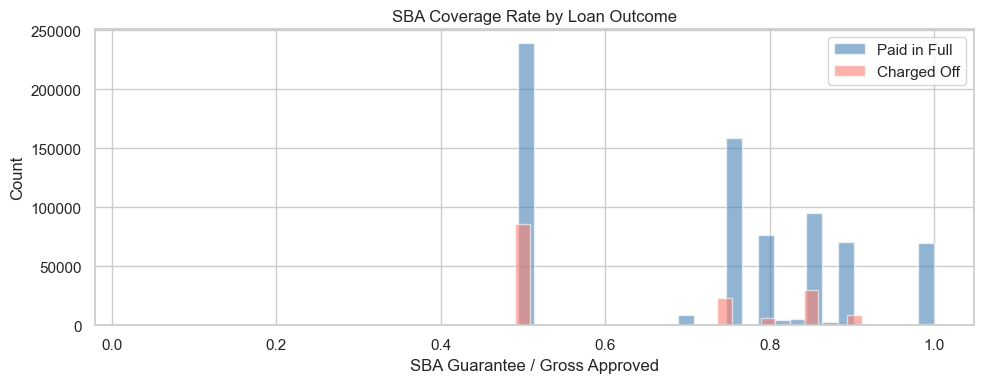

Mean SBA coverage by outcome:
MIS_Status
CHGOFF    0.644
P I F     0.724
Name: SBA_coverage, dtype: float64


In [11]:
# SBA_coverage = proportion of the loan guaranteed by the SBA
# A higher value means the bank bears less risk — this may influence lending behaviour
labelled["SBA_coverage"] = labelled["SBA_Appv"] / labelled["GrAppv"]

fig, ax = plt.subplots(figsize=(10, 4))
for status, color, label in [("P I F", "steelblue", "Paid in Full"), ("CHGOFF", "salmon", "Charged Off")]:
    ax.hist(
        labelled.loc[labelled["MIS_Status"] == status, "SBA_coverage"].dropna().clip(0, 1),
        bins=50, alpha=0.6, label=label, color=color
    )
ax.set_xlabel("SBA Guarantee / Gross Approved")
ax.set_ylabel("Count")
ax.set_title("SBA Coverage Rate by Loan Outcome")
ax.legend()
plt.tight_layout()
plt.show()

# Compare mean coverage rate between outcomes
print("Mean SBA coverage by outcome:")
print(labelled.groupby("MIS_Status")["SBA_coverage"].mean().round(3))

Defaulted loans tend to have a **higher SBA coverage ratio** — the SBA guaranteed a larger share of these loans. This may reflect the SBA taking on riskier loans, or banks being less selective when more of the risk is backed by the government.

## 9. Default Rate by Approval Year

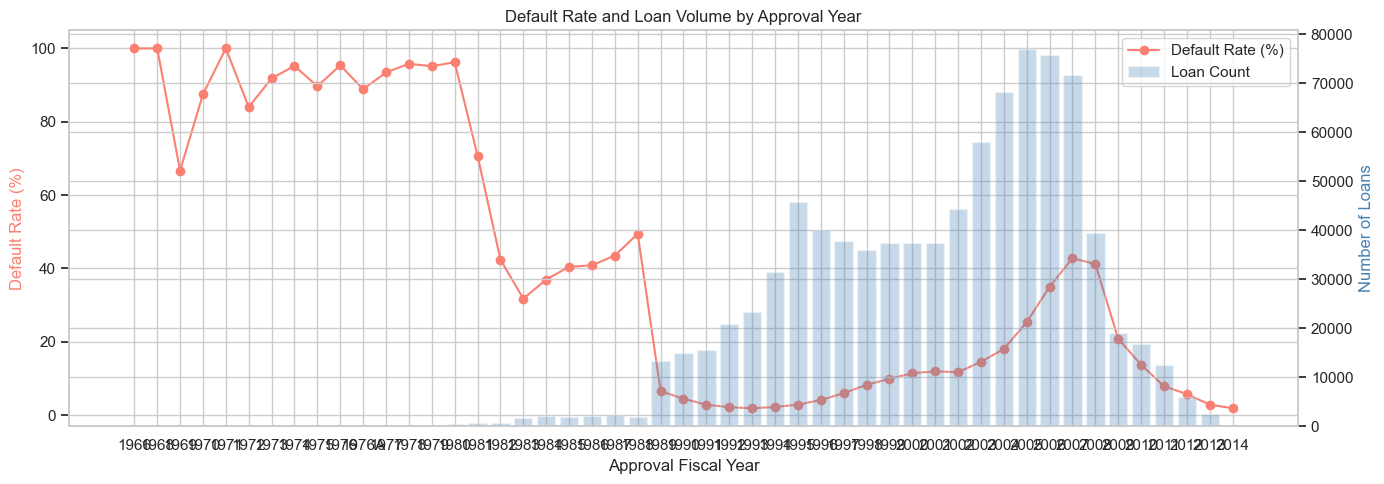

In [12]:
# Aggregate default rate and loan count per fiscal year
yearly = (
    labelled.groupby("ApprovalFY")["Defaulted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n"})
)

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()  # share the x-axis, use a second y-axis for loan volume

# Line: default rate trend over time
ax1.plot(yearly.index, yearly["default_rate"] * 100, color="salmon", marker="o", label="Default Rate (%)")
# Bar: number of loans approved each year (context for rate spikes)
ax2.bar(yearly.index, yearly["n"], alpha=0.3, color="steelblue", label="Loan Count")

ax1.set_xlabel("Approval Fiscal Year")
ax1.set_ylabel("Default Rate (%)", color="salmon")
ax2.set_ylabel("Number of Loans", color="steelblue")
ax1.set_title("Default Rate and Loan Volume by Approval Year")

# Combine legends from both axes into one
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

Default rates spiked sharply for loans approved around **2006–2008**, coinciding with the Global Financial Crisis. Loans approved after 2010 show lower default rates as lending standards tightened. `ApprovalFY` captures important macroeconomic context and should be included in any model.

## 10. Correlation Heatmap (Numeric Features)

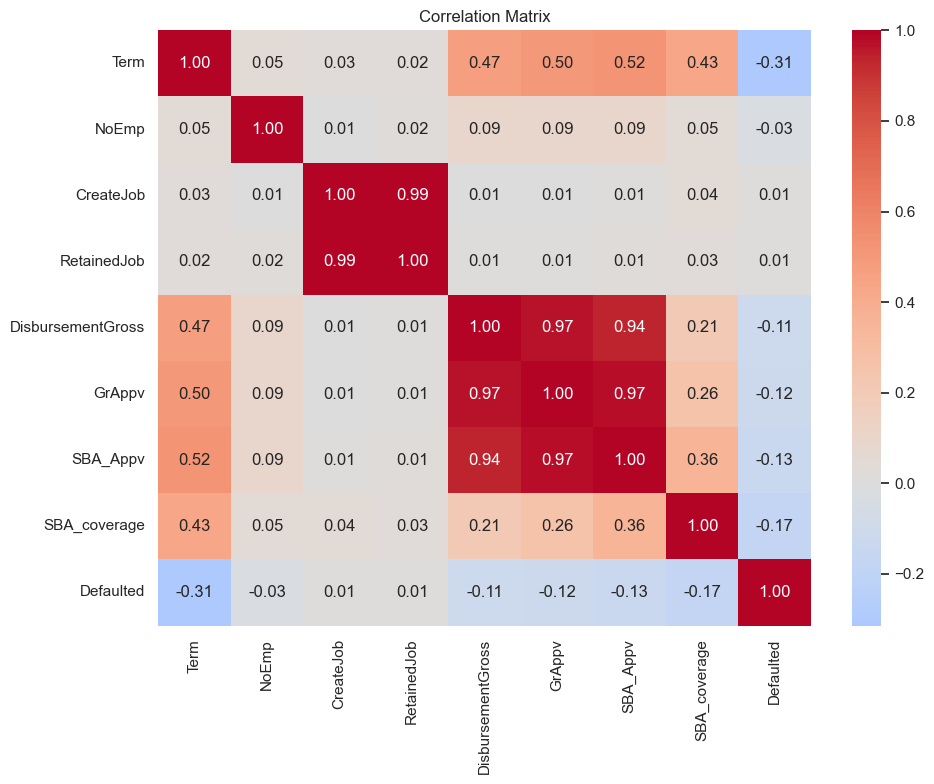

In [13]:
# Include the binary target so we can see which features correlate with default
corr_cols = ["Term", "NoEmp", "CreateJob", "RetainedJob",
             "DisbursementGross", "GrAppv", "SBA_Appv", "SBA_coverage", "Defaulted"]

corr = labelled[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
# annot=True prints the correlation value in each cell; center=0 anchors the colour scale at zero
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation Matrix")
plt.tight_layout()
plt.show()

Loan amount columns (`GrAppv`, `SBA_Appv`, `DisbursementGross`) are highly correlated with each other — using all three in a model would introduce multicollinearity. `Term` has the strongest individual correlation with default among numeric features, though all correlations are modest, suggesting non-linear models may perform better.

## 11. Top Industries by Default Rate (NAICS 2-digit sector)

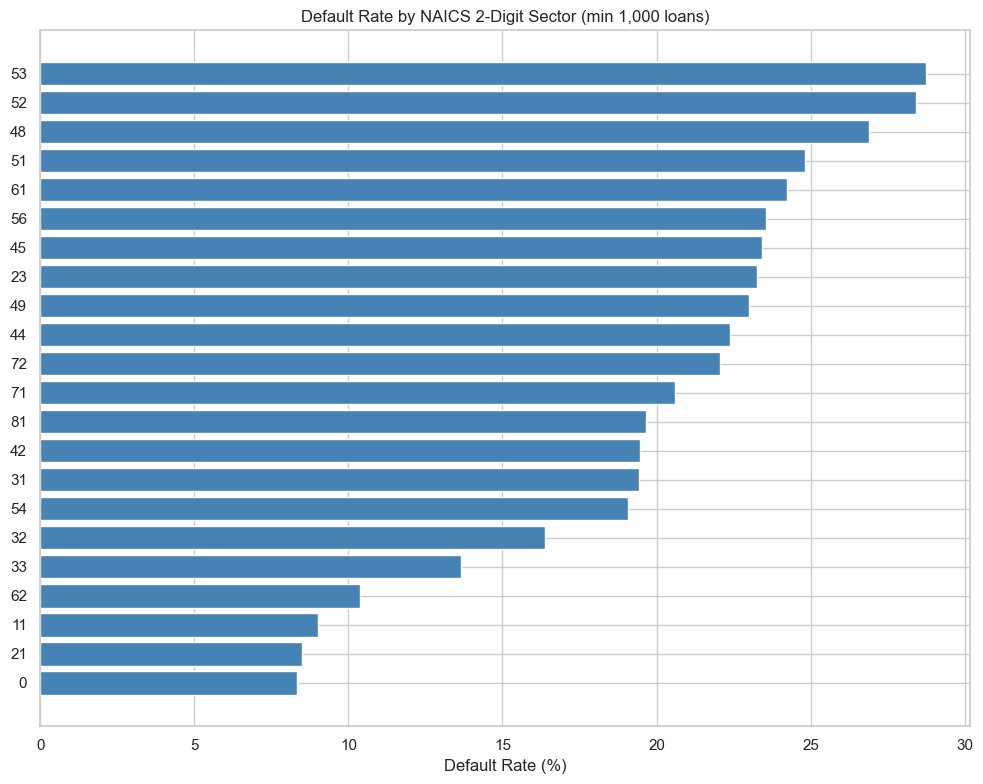

In [14]:
# NAICS codes are 6 digits; the first 2 identify the broad industry sector
labelled["NAICS2"] = labelled["NAICS"].astype(str).str[:2]

naics_rates = (
    labelled.groupby("NAICS2")["Defaulted"]
    .agg(["mean", "count"])
    .rename(columns={"mean": "default_rate", "count": "n"})
    .query("n >= 1000")           # exclude sectors with too few loans for a reliable rate
    .sort_values("default_rate", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(naics_rates.index, naics_rates["default_rate"] * 100, color="steelblue")
ax.set_xlabel("Default Rate (%)")
ax.set_title("Default Rate by NAICS 2-Digit Sector (min 1,000 loans)")
plt.tight_layout()
plt.show()

Industry sector is a meaningful predictor — default rates vary widely across NAICS sectors. Sectors like accommodation & food services (72) and retail (44–45) tend to have higher default rates, while professional services and manufacturing show lower rates. This aligns with the general risk profile of those industries.

## 12. Key Takeaways

- **~17% of labelled loans defaulted** — a moderately imbalanced classification problem.
- **New businesses default at a significantly higher rate** than existing ones.
- **Loan term** is positively correlated with default — longer terms carry more risk.
- **SBA guarantee coverage** differs between outcomes, suggesting it may be a useful feature.
- **Approval year matters** — default rates spiked around the 2008–2010 financial crisis.
- **NAICS sector** shows strong variation in default rates; industry is an important predictor.
- **Several columns need cleaning** before modelling: currency strings, date parsing, flag encoding (NewExist, RevLineCr, LowDoc, UrbanRural).

## 13. Understanding the Business Problem 

*Decide to approve or decline loan application for a given businesses*
> Evaluate Risk based on historical data

When using a Model:
> Model predicts probobility of default
$P(\text{default})$

### Decision Rule
- If $P(\text{default})$
 ≤ 0.5 → Approve
- If $P(\text{default})$ > 0.5 → Deny

> ***Bonus*** Predict optimal credit amount for a given venture